# Evaluation of Vision Models

## 1 Overview

## 2 Importing Libraries

In [1]:
from pathlib import Path
import gc
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, f1_score, precision_score, recall_score
from transformers import pipeline
import timm
from huggingface_hub import hf_hub_download
from timm.data import resolve_model_data_config, create_transform
import sys
from torchvision import transforms

c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3 Evaluation Settings and Candidate Models

In [2]:
# Reproducible evaluation
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

# Use GPU when available
device = 0 if torch.cuda.is_available() else -1

In [3]:
# RAF-DB folders and label files
rafdb_folder = Path(
    "../../data/raw/raf_db"
)

dataset_folder = (
    rafdb_folder / "DATASET"
)

validation_folder = (
    dataset_folder / "train"
)

testing_folder = (
    dataset_folder / "test"
)

validation_labels_file = (
    rafdb_folder / "train_labels.csv"
)

testing_labels_file = (
    rafdb_folder / "test_labels.csv"
)

# Output folder
output_folder = Path("outputs/vision")

output_folder.mkdir(
    parents=True,
    exist_ok=True
)

In [4]:
# Seven RAF-DB emotion classes
vision_emotions = [
    "anger",
    "disgust",
    "fear",
    "happiness",
    "neutral",
    "sadness",
    "surprise"
]

In [5]:
# Candidate facial-expression models
models = {
    "ViT": {
        "model_id": (
            "trpakov/"
            "vit-face-expression"
        ),
        "architecture": "Vision Transformer",
        "training_data": "FER2013",
        "batch_size": 16
    },

    "ResNet-50": {
        "model_id": (
            "Celal11/"
            "resnet-50-finetuned-FER2013-0.003"
        ),
        "architecture": "ResNet-50",
        "training_data": "FER2013",
        "batch_size": 16
    },

    "ViT-Mixed-Datasets": {
        "model_id": (
            "mo-thecreator/"
            "vit-Facial-Expression-Recognition"
        ),
        "architecture": "Vision Transformer",
        "training_data": (
            "FER2013, MMI and AffectNet"
        ),
        "batch_size": 16
    },

    "ViT-FER2013": {
        "model_id": (
            "abhilash88/"
            "face-emotion-detection"
        ),
        "architecture": "Vision Transformer",
        "training_data": "FER2013",
        "batch_size": 16
    },

    "ConvNeXt-Tiny": {
        "model_id": (
            "Aaryan333/"
            "convnext-tiny-finetuned-fer2013"
        ),
        "architecture": "ConvNeXt-Tiny",
        "training_data": "FER2013",
        "batch_size": 16
    },

    "Swin-Tiny": {
        "model_id": (
            "Ram9999Pabb/"
            "emotion-swin-model"
        ),
        "architecture": "Swin Transformer",
        "training_data": "FER2013",
        "batch_size": 16,
        "loader": "swin_custom"
    },
    "DDAMFN-AffectNet7": {
        "architecture": "DDAMFN (MixedFeatureNet)",
        "training_data": "AffectNet-7",
        "batch_size": 1,
        "loader": "ddamfn"
    },

}

In [6]:
model_information = []

for model_name, details in models.items():
    model_information.append({
        "Model": model_name,
        "Architecture": details["architecture"],
        "Training Data": details["training_data"],
        "RAF-DB Training": "Not reported",
        "Batch Size": details["batch_size"]
    })

model_information_df = pd.DataFrame(
    model_information
)

display(model_information_df)

print("Number of models:", len(models))
print("Emotions:", vision_emotions)

,Model,Architecture,Training Data,RAF-DB Training,Batch Size
0,ViT,Vision Transformer,FER2013,Not reported,16
1,ResNet-50,ResNet-50,FER2013,Not reported,16
2,ViT-Mixed-Datasets,Vision Transformer,"FER2013, MMI and AffectNet",Not reported,16
3,ViT-FER2013,Vision Transformer,FER2013,Not reported,16
4,ConvNeXt-Tiny,ConvNeXt-Tiny,FER2013,Not reported,16
5,Swin-Tiny,Swin Transformer,FER2013,Not reported,16
6,DDAMFN-AffectNet7,DDAMFN (MixedFeatureNet),AffectNet-7,Not reported,1


Number of models: 7
Emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


## 4 Load RAF-DB Dataset

In [7]:
label_mapping = {
    1: "surprise",
    2: "fear",
    3: "disgust",
    4: "happiness",
    5: "sadness",
    6: "anger",
    7: "neutral"
}

In [8]:
def load_rafdb_split(labels_file, image_folder):
    data = pd.read_csv(labels_file)

    data = data[["image", "label"]].copy()

    data["emotion"] = data["label"].map(
        label_mapping
    )
    data["image_path"] = data.apply(
        lambda row: (
            image_folder
            / str(row["label"])
            / str(row["image"])
        ),
        axis=1
    )

    missing_files = (
        ~data["image_path"].apply(
            lambda path: path.is_file()
        )
    )

    if missing_files.any():
        raise FileNotFoundError(
            f"{missing_files.sum()} images "
            f"could not be located."
        )

    return data.reset_index(drop=True)

In [9]:
validation_data = load_rafdb_split(
    validation_labels_file,
    validation_folder
)

testing_data = load_rafdb_split(
    testing_labels_file,
    testing_folder
)

print(
    "Validation images:",
    len(validation_data)
)

print(
    "Testing images:",
    len(testing_data)
)

Validation images: 12271
Testing images: 3068


In [10]:
class_distribution = pd.concat([
    validation_data["emotion"]
    .value_counts()
    .reindex(vision_emotions)
    .rename("Validation"),

    testing_data["emotion"]
    .value_counts()
    .reindex(vision_emotions)
    .rename("Testing")
], axis=1).fillna(0).astype(int)

display(class_distribution)

,Validation,Testing
emotion,,
anger,705,162
disgust,717,160
fear,281,74
happiness,4772,1185
neutral,2524,680
sadness,1982,478
surprise,1290,329


## 5 Align Emotion Labels and Prepare Images

In [11]:
label_aliases = {
    "angry": "anger",
    "anger": "anger",

    "disgusted": "disgust",
    "disgust": "disgust",

    "fearful": "fear",
    "fear": "fear",

    "happy": "happiness",
    "happiness": "happiness",
    "joy": "happiness",

    "neutral": "neutral",

    "sad": "sadness",
    "sadness": "sadness",

    "surprised": "surprise",
    "surprise": "surprise",

    "label_0": "anger",
    "label_1": "disgust",
    "label_2": "fear",
    "label_3": "happiness",
    "label_4": "sadness",
    "label_5": "surprise",
    "label_6": "neutral"
}


def normalise_vision_label(label):
    label = str(label).strip().lower()

    return label_aliases.get(
        label,
        label
    )

In [12]:
def load_image(image_path):
    return Image.open(
        image_path
    ).convert("RGB")

In [13]:
sample_image = load_image(
    validation_data.loc[
        0,
        "image_path"
    ]
)

print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)
print(
    "Dataset emotions:",
    sorted(
        validation_data["emotion"].unique()
    )
)

Image size: (100, 100)
Image mode: RGB
Dataset emotions: ['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


## 6 Define Model Prediction Functions

In [14]:
def run_vision_model(model_details, data):
    model_id = model_details["model_id"]
    batch_size = model_details["batch_size"]

    loading_start = time.perf_counter()

    classifier = pipeline(
        task="image-classification",
        model=model_id,
        device=device,
        top_k=None
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    loading_time = (
        time.perf_counter() - loading_start
    )

    predictions = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    for start_index in range(
        0,
        len(data),
        batch_size
    ):
        batch = data.iloc[
            start_index:
            start_index + batch_size
        ]

        images = [
            load_image(image_path)
            for image_path in batch["image_path"]
        ]

        batch_outputs = classifier(
            images,
            batch_size=batch_size
        )

        if (
            batch_outputs
            and isinstance(batch_outputs[0], dict)
        ):
            batch_outputs = [batch_outputs]

        for prediction_scores in batch_outputs:
            common_scores = {}

            for item in prediction_scores:
                emotion = normalise_vision_label(
                    item["label"]
                )

                if emotion in vision_emotions:
                    common_scores[emotion] = float(
                        item["score"]
                    )

            if not common_scores:
                raise ValueError(
                    "The model returned no supported "
                    "emotion labels."
                )

            predictions.append(
                max(
                    common_scores,
                    key=common_scores.get
                )
            )

        for image in images:
            image.close()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - inference_start
    )

    del classifier

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "predictions": predictions,
        "loading_time": loading_time,
        "inference_time": inference_time
    }

In [15]:
def run_swin_model(model_details, data):
    model_id = model_details["model_id"]
    batch_size = model_details["batch_size"]

    torch_device = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

    swin_labels = [
        "anger",
        "disgust",
        "fear",
        "happiness",
        "sadness",
        "surprise",
        "neutral"
    ]

    loading_start = time.perf_counter()

    weights_path = hf_hub_download(
        repo_id=model_id,
        filename="model.pth"
    )

    model = timm.create_model(
        "swin_tiny_patch4_window7_224",
        pretrained=False,
        num_classes=7
    )

    checkpoint = torch.load(
        weights_path,
        map_location=torch_device
    )

    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    else:
        state_dict = checkpoint

    state_dict = {
        key.replace("module.", ""): value
        for key, value in state_dict.items()
    }

    model.load_state_dict(state_dict)

    model = model.to(torch_device)
    model.eval()

    data_config = resolve_model_data_config(
        model
    )

    transform = create_transform(
        **data_config,
        is_training=False
    )

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    loading_time = (
        time.perf_counter() - loading_start
    )

    predictions = []

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_start = time.perf_counter()

    with torch.inference_mode():

        for start_index in range(
            0,
            len(data),
            batch_size
        ):
            batch = data.iloc[
                start_index:
                start_index + batch_size
            ]

            images = [
                load_image(image_path)
                for image_path in batch["image_path"]
            ]

            image_tensors = torch.stack([
                transform(image)
                for image in images
            ]).to(torch_device)

            outputs = model(image_tensors)

            predicted_indices = (
                outputs.argmax(dim=1)
                .cpu()
                .tolist()
            )

            predictions.extend([
                swin_labels[index]
                for index in predicted_indices
            ])

            for image in images:
                image.close()

    if torch.cuda.is_available():
        torch.cuda.synchronize()

    inference_time = (
        time.perf_counter() - inference_start
    )

    del model

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return {
        "predictions": predictions,
        "loading_time": loading_time,
        "inference_time": inference_time
    }

In [16]:
DDAMFN_DIR = r"C:\Users\Subathra\OneDrive\Desktop\Models\DDAMFN\DDAMFN++"
DDAMFN_CKPT = r"C:\Users\Subathra\OneDrive\Desktop\Models\DDAMFN\DDAMFN++\checkpoints_ver2.0\affecnet7_epoch19_acc0.671.pth"

if DDAMFN_DIR not in sys.path:
    sys.path.insert(0, DDAMFN_DIR)

from networks.DDAM import DDAMNet
# DDAMFN output index -> your emotion strings (their class7_names order)
DDAMFN_INDEX_TO_EMOTION = {
    0: "neutral", 1: "happiness", 2: "sadness", 3: "surprise",
    4: "fear", 5: "disgust", 6: "anger",
}

_ddamfn_tf = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def run_ddamfn_model(model_details, data):
    dev = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    loading_start = time.perf_counter()
    model = DDAMNet(num_class=7, num_head=2, pretrained=False)
    checkpoint = torch.load(DDAMFN_CKPT, map_location=dev)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(dev).eval()
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    loading_time = time.perf_counter() - loading_start

    predictions = []
    processing_start = time.perf_counter()
    with torch.inference_mode():
        for image_path in data["image_path"]:
            image = Image.open(image_path).convert("RGB")
            tensor = _ddamfn_tf(image).unsqueeze(0).to(dev)
            out, _, _ = model(tensor)
            index = int(torch.argmax(out, dim=1).item())
            predictions.append(DDAMFN_INDEX_TO_EMOTION[index])
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    processing_time = time.perf_counter() - processing_start

    return {
        "predictions": predictions,
        "loading_time": loading_time,
        "inference_time": processing_time,
    }

## 7 Model Evaluation on Validation Data

In [17]:
def calculate_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(
            actual,
            predicted
        ),
        "Macro Precision": precision_score(
            actual,
            predicted,
            labels=vision_emotions,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            actual,
            predicted,
            labels=vision_emotions,
            average="macro",
            zero_division=0
        ),
        "Macro-F1": f1_score(
            actual,
            predicted,
            labels=vision_emotions,
            average="macro",
            zero_division=0
        )
    }

In [18]:
validation_results = []
validation_predictions = {}

actual_validation_labels = (
    validation_data["emotion"].tolist()
)

for model_name, model_details in models.items():
    print(f"Evaluating {model_name}...")

    if model_details.get("loader") == "swin_custom":
        evaluation = run_swin_model(model_details, validation_data)
    elif model_details.get("loader") == "ddamfn":
        evaluation = run_ddamfn_model(model_details, validation_data)
    else:
        evaluation = run_vision_model(model_details, validation_data)

    predicted_labels = evaluation["predictions"]

    if len(predicted_labels) != len(
        actual_validation_labels
    ):
        raise ValueError(
            f"{model_name} returned an incorrect "
            "number of predictions."
        )

    metrics = calculate_metrics(
        actual_validation_labels,
        predicted_labels
    )

    validation_predictions[model_name] = (
        predicted_labels
    )

    validation_results.append({
        "Model": model_name,
        **metrics,
        "Loading Time": evaluation["loading_time"],
        "Processing Time": evaluation["inference_time"],
        "ms per Image": (
            evaluation["inference_time"]
            / len(validation_data)
            * 1000
        )
    })

    print(
        "Macro-F1:",
        round(metrics["Macro-F1"], 4)
    )

Evaluating ViT...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Macro-F1: 0.4997
Evaluating ResNet-50...


Device set to use cuda:0


Macro-F1: 0.4927
Evaluating ViT-Mixed-Datasets...


...

Macro-F1: 0.5826
Evaluating ViT-FER2013...


Device set to use cuda:0


Macro-F1: 0.5034
Evaluating ConvNeXt-Tiny...


c:\Users\Subathra\OneDrive\Desktop\cm3020_Final_Year_project\CM3020_Final_Year_Project\.venv\Lib\site-packages\transformers\models\convnext\feature_extraction_convnext.py:30: FutureWarning: The class ConvNextFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ConvNextImageProcessor instead.
  warnings.warn(
Device set to use cuda:0


Macro-F1: 0.4479
Evaluating Swin-Tiny...
Macro-F1: 0.2219
Evaluating DDAMFN-AffectNet7...
Macro-F1: 0.648


In [19]:
validation_results_df = pd.DataFrame(
    validation_results
)

display(validation_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Processing Time,ms per Image
0,ViT,0.643224,0.590677,0.543477,0.499665,1.268748,98.990664,8.067041
1,ResNet-50,0.589520,0.543076,0.518933,0.492742,1.266310,55.911058,4.556357
2,ViT-Mixed-Datasets,0.699454,0.593050,0.607730,0.582624,1.008435,111.030045,9.048166
3,ViT-FER2013,0.656996,0.580989,0.534455,0.503429,0.923579,119.811932,9.763828
4,ConvNeXt-Tiny,0.603863,0.532898,0.481285,0.447915,1.227776,79.342849,6.465883
5,Swin-Tiny,0.370874,0.233270,0.241181,0.221887,0.802976,62.050286,5.056661
6,DDAMFN-AffectNet7,0.768967,0.646171,0.697485,0.648036,0.920245,381.411783,31.082372


## 8 Comparing and Selecting the Best Model

In [20]:
validation_results_df = (
    validation_results_df
    .sort_values(
        by=["Macro-F1", "Processing Time"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)

display(validation_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Processing Time,ms per Image
0,DDAMFN-AffectNet7,0.768967,0.646171,0.697485,0.648036,0.920245,381.411783,31.082372
1,ViT-Mixed-Datasets,0.699454,0.593050,0.607730,0.582624,1.008435,111.030045,9.048166
2,ViT-FER2013,0.656996,0.580989,0.534455,0.503429,0.923579,119.811932,9.763828
3,ViT,0.643224,0.590677,0.543477,0.499665,1.268748,98.990664,8.067041
4,ResNet-50,0.589520,0.543076,0.518933,0.492742,1.266310,55.911058,4.556357
5,ConvNeXt-Tiny,0.603863,0.532898,0.481285,0.447915,1.227776,79.342849,6.465883
6,Swin-Tiny,0.370874,0.233270,0.241181,0.221887,0.802976,62.050286,5.056661


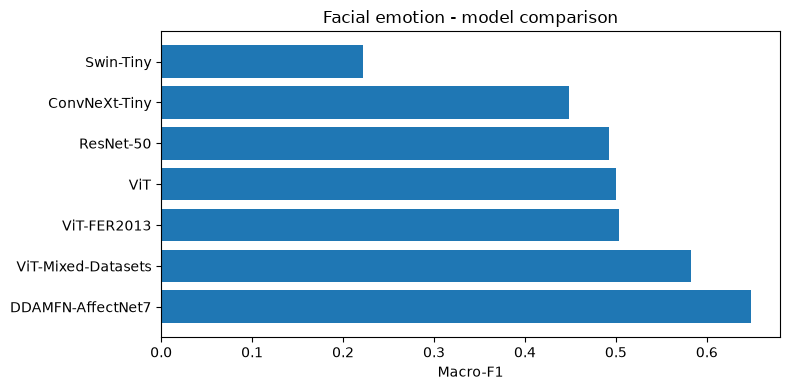

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.barh(validation_results_df["Model"], validation_results_df["Macro-F1"])
plt.xlabel("Macro-F1")
plt.title("Facial emotion - model comparison")
plt.tight_layout()
plt.show()

In [22]:
selected_model_name = validation_results_df.loc[
    0,
    "Model"
]

selected_model_details = models[
    selected_model_name
]

selected_validation_predictions = (
    validation_predictions[
        selected_model_name
    ]
)

print(
    "Selected model:",
    selected_model_name
)

print(
    "Validation Macro-F1:",
    round(
        validation_results_df.loc[
            0,
            "Macro-F1"
        ],
        4
    )
)

print(
    "Inference time:",
    round(
        validation_results_df.loc[
            0,
            "Processing Time"
        ],
        2
    ),
    "seconds"
)

print(
    "Processing time:",
    round(
        validation_results_df.loc[
            0,
            "ms per Image"
        ],
        2
    ),
    "ms per image"
)

Selected model: DDAMFN-AffectNet7
Validation Macro-F1: 0.648
Inference time: 381.41 seconds
Processing time: 31.08 ms per image


## 9 Final Test Evaluation

In [23]:
actual_test_labels = (
    testing_data["emotion"].tolist()
)

if selected_model_details.get("loader") == "swin_custom":
    test_evaluation = run_swin_model(
        selected_model_details,
        testing_data
    )
elif selected_model_details.get("loader") == "ddamfn":
    test_evaluation = run_ddamfn_model(
        selected_model_details,
        testing_data
    )
else:
    test_evaluation = run_vision_model(
        selected_model_details,
        testing_data
    )

test_predictions = (
    test_evaluation["predictions"]
)

if len(test_predictions) != len(
    actual_test_labels
):
    raise ValueError(
        "The selected model returned an incorrect "
        "number of test predictions."
    )

In [24]:
test_metrics = calculate_metrics(
    actual_test_labels,
    test_predictions
)

test_results_df = pd.DataFrame([{
    "Model": selected_model_name,
    **test_metrics,
    "Loading Time": test_evaluation["loading_time"],
    "Processing Time": test_evaluation["inference_time"],
    "ms per Image": (
        test_evaluation["inference_time"]
        / len(testing_data)
        * 1000
    )
}])

display(test_results_df)

,Model,Accuracy,Macro Precision,Macro Recall,Macro-F1,Loading Time,Processing Time,ms per Image
0,DDAMFN-AffectNet7,0.768579,0.644476,0.699152,0.64157,0.298136,95.49263,31.125368


In [25]:
print(
    "Selected model:",
    selected_model_name
)

print(
    "Test Macro-F1:",
    round(
        test_metrics["Macro-F1"],
        4
    )
)

print(
    "Test Accuracy:",
    round(
        test_metrics["Accuracy"],
        4
    )
)

print(
    "Processing time:",
    round(
        test_results_df.loc[
            0,
            "ms per Image"
        ],
        2
    ),
    "ms per image"
)

Selected model: DDAMFN-AffectNet7
Test Macro-F1: 0.6416
Test Accuracy: 0.7686
Processing time: 31.13 ms per image


## 10 Confusion Matrix

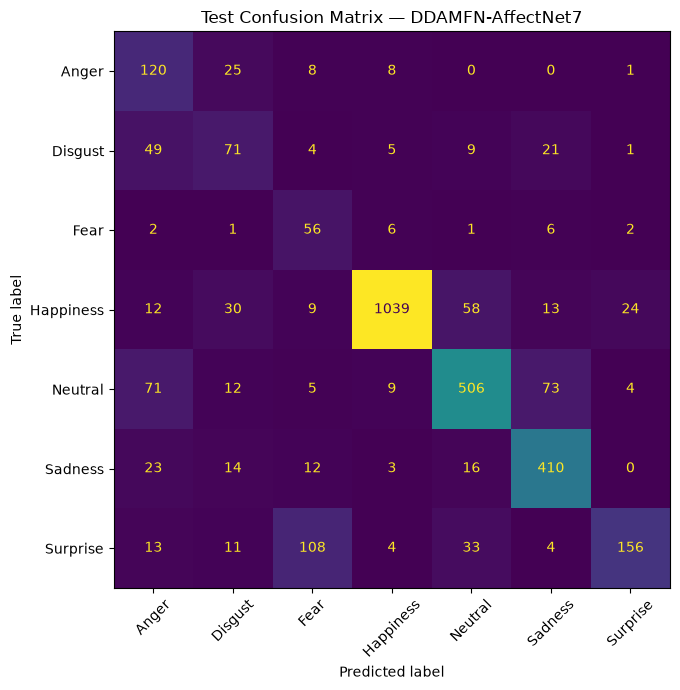

In [26]:
figure, axis = plt.subplots(
    figsize=(8, 7)
)

ConfusionMatrixDisplay.from_predictions(
    actual_test_labels,
    test_predictions,
    labels=vision_emotions,
    display_labels=[
        emotion.capitalize()
        for emotion in vision_emotions
    ],
    xticks_rotation=45,
    ax=axis,
    colorbar=False
)

axis.set_title(
    f"Test Confusion Matrix — {selected_model_name}"
)

plt.tight_layout()

plt.savefig(
    output_folder
    / "selected_vision_model_confusion_matrix.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()
plt.close()

In [27]:
per_class_precision = precision_score(
    actual_test_labels,
    test_predictions,
    labels=vision_emotions,
    average=None,
    zero_division=0
)

per_class_recall = recall_score(
    actual_test_labels,
    test_predictions,
    labels=vision_emotions,
    average=None,
    zero_division=0
)

per_class_f1 = f1_score(
    actual_test_labels,
    test_predictions,
    labels=vision_emotions,
    average=None,
    zero_division=0
)

class_support = (
    pd.Series(actual_test_labels)
    .value_counts()
    .reindex(vision_emotions, fill_value=0)
    .values
)

per_class_results_df = pd.DataFrame({
    "Emotion": [
        emotion.capitalize()
        for emotion in vision_emotions
    ],
    "Precision": per_class_precision,
    "Recall": per_class_recall,
    "F1-Score": per_class_f1,
    "Support": class_support
})

display(per_class_results_df)

,Emotion,Precision,Recall,F1-Score,Support
0,Anger,0.413793,0.740741,0.530973,162
1,Disgust,0.432927,0.443750,0.438272,160
2,Fear,0.277228,0.756757,0.405797,74
3,Happiness,0.967412,0.876793,0.919876,1185
4,Neutral,0.812199,0.744118,0.776669,680
5,Sadness,0.777989,0.857741,0.815920,478
6,Surprise,0.829787,0.474164,0.603482,329


## 11 Saving Results

In [28]:
validation_results_df.to_csv(
    output_folder / "vision_model_comparison.csv",
    index=False
)

test_results_df.to_csv(
    output_folder / "selected_vision_model_test_results.csv",
    index=False
)

In [29]:
test_predictions_df = pd.DataFrame({
    "Image": testing_data["image"],
    "Actual Emotion": actual_test_labels,
    "Predicted Emotion": test_predictions
})

test_predictions_df.to_csv(
    output_folder / "selected_vision_model_test_predictions.csv",
    index=False
)

print("Results saved in:", output_folder)

Results saved in: outputs\vision


## 12 Conclusion